# Module 04 — Your First Machine-Learning Model

*Teaching a computer to identify penguins.*

Same penguins as Module 02: 344 birds of three species (Adélie, Chinstrap, Gentoo) measured between 2007 and 2009 by Dr. Kristen Gorman and the Palmer Station Long-Term Ecological Research program in Antarctica. In Module 02 we *described* them; today we give the data a job. A field biologist can identify a penguin's species at a glance — a skill built from seeing many penguins whose species someone confirmed. Can a computer acquire the same skill from 333 measured, labeled examples?

This is **supervised learning**: show the computer examples *with the correct answers attached*, let it find the pattern, then grade it — strictly on penguins it has never seen. Our model is **k-nearest neighbors (k-NN)**, machine learning's version of BLAST: identify the unknown by looking up its closest matches.

Run each cell in order; predict before you run. Every non-obvious line has a `#` comment explaining it.

In [1]:
import numpy as np                # arrays (Module 01)
import pandas as pd               # tables (Module 02)
import matplotlib.pyplot as plt   # drawing plots
import seaborn as sns             # nicer-looking plots

sns.set_theme(style="whitegrid", palette="colorblind")

# Same fixed species colors as Modules 01 and 02.
palette = sns.color_palette("colorblind")
SPECIES_COLORS = {"Adelie": palette[0], "Chinstrap": palette[1], "Gentoo": palette[2]}

## 1. Load and clean — same ritual as Module 02

Same dataset, same cleaning ritual as Module 02: download, convert to a DataFrame, and `dropna()` the 11 incomplete rows (we reasoned through that decision there — for measurement-based work those rows are unusable).

In [2]:
from datasets import load_dataset   # the HuggingFace downloader (Modules 01-02)

# Download the penguins, convert to a pandas table, drop incomplete rows.
raw = load_dataset("SIH/palmer-penguins", split="train").to_pandas()
df = raw.dropna()   # a NEW table with every incomplete row removed

print(f"kept {len(df)} of {len(raw)} penguins")
df.head()

kept 333 of 344 penguins


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


## 2. Features X and label y

To turn a table into a *learning problem*, we point at two things:

- **Features `X`** — the columns the model may use to make its guess. Capital `X` because it's a whole table (many columns). These are the measurable *characters* of each specimen.
- **Label `y`** — the answer column: the species the field biologists recorded. Lowercase `y` because it's a single column.

These names are a universal convention — every scikit-learn function expects them in this order: `(X, y)`.

We start with only **two** features, bill length and bill depth. Not because more is worse (we'll use all four at the end) — but because with two features every penguin is a dot on a flat plot, and we can *watch* the model think.

In [3]:
# X = the feature table: just the two bill measurements (note the double [[ ]]
# from Module 02 -- a list of column names selects a smaller table).
X = df[["bill_length_mm", "bill_depth_mm"]]

# y = the label column: the answer we want the model to learn to produce.
y = df["species"]

print("X is a table with shape:", X.shape)   # (rows, columns)
print("y is one column with", len(y), "answers")
X.head()

X is a table with shape: (333, 2)
y is one column with 333 answers


,bill_length_mm,bill_depth_mm
0,39.1,18.7
1,39.5,17.4
2,40.3,18.0
4,36.7,19.3
5,39.3,20.6


## 3. The train/test split

The exam rule from the README: a student who memorizes the answer key can ace a test *they have already seen* while having learned nothing. So before any training, we lock 20% of the penguins in a drawer:

- **training set** (80%) — the textbook; the model studies these rows, answers included
- **test set** (20%) — the final exam; the model meets these penguins only when we grade it

`train_test_split` shuffles the rows and cuts them. Two options matter:

- `random_state=42` — fixes the shuffle, so every run (and every reader) gets the *identical* split. Like recording your randomization seed in a methods section.
- `stratify=y` — keeps the species proportions equal in both pieces, like stratified sampling in field ecology. Otherwise a random cut could put nearly all the rare Chinstraps in one piece.

In [4]:
# train_test_split is our first import from scikit-learn (sklearn),
# THE Python library for classical machine learning.
from sklearn.model_selection import train_test_split

# One call returns FOUR pieces, always in this order:
# features-for-training, features-for-testing, labels-for-training, labels-for-testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% of rows go into the test set
    random_state=42,    # fixed shuffle -> same split every run
    stratify=y)         # keep species proportions equal in both pieces

print("training penguins:", len(X_train))
print("test penguins:    ", len(X_test))

training penguins: 266
test penguins:     67


In [5]:
# Did stratify work? Compare species FRACTIONS in the two pieces.
# value_counts(normalize=True) gives fractions instead of raw counts.
print("training set species mix:")
print(y_train.value_counts(normalize=True).round(2))
print()
print("test set species mix:")
print(y_test.value_counts(normalize=True).round(2))

training set species mix:
species
Adelie       0.44
Gentoo       0.36
Chinstrap    0.20
Name: proportion, dtype: float64

test set species mix:
species
Adelie       0.43
Gentoo       0.36
Chinstrap    0.21
Name: proportion, dtype: float64


## 4. Training k-NN — let 5 similar penguins vote

How does **k-nearest neighbors** classify a mystery penguin? Plot it among the training penguins, find the **k** closest ones (closest on the plot = most similar measurements), and let them **vote**. With `k=5`: if 4 neighbors are Gentoo and 1 is Chinstrap, the verdict is Gentoo. That's the whole algorithm — BLAST logic, for measurements.

Two scikit-learn verbs to learn, used by *every* model in the library:

- `.fit(X_train, y_train)` — "learn from these examples." This is the training step.
- `.predict(X_new)` — "give me your answer for these new rows."

For k-NN, `.fit` simply files the training penguins away, like a museum storing labeled reference specimens — the real work (measuring distances, voting) happens at prediction time.

In [6]:
# KNeighborsClassifier is the k-NN model; 'neighbors' is its sklearn family.
from sklearn.neighbors import KNeighborsClassifier

# Create the model. n_neighbors=5 means 'let the 5 closest penguins vote'.
knn = KNeighborsClassifier(n_neighbors=5)

# Train it: hand over the training features AND their correct answers.
knn.fit(X_train, y_train)

# Now ask it to identify every penguin in the test set (answers NOT shown to it).
predictions = knn.predict(X_test)

# Line up the first 8 guesses against the truth.
# .values pulls the plain values out of y_test so the rows pair up cleanly.
comparison = pd.DataFrame({"model's guess": predictions[:8],
                           "actual species": y_test.values[:8]})
comparison

,model's guess,actual species
0,Gentoo,Gentoo
1,Chinstrap,Chinstrap
2,Adelie,Adelie
3,Gentoo,Gentoo
4,Gentoo,Gentoo
5,Gentoo,Gentoo
6,Chinstrap,Chinstrap
7,Adelie,Adelie


## 5. Accuracy — grading the exam

**Accuracy** = the fraction of predictions that are correct. `.score(X, y)` computes it in one step: predict for every row of `X`, compare with `y`, return the fraction right.

We compute it twice — on the exam (test set) and, for contrast, on the textbook (training set).

In [7]:
# The score that counts: accuracy on penguins the model has never seen.
test_accuracy = knn.score(X_test, y_test)

# The flattering score: accuracy on the very penguins it trained on.
train_accuracy = knn.score(X_train, y_train)

# ':.3f' inside an f-string means 'show 3 decimal places'.
print(f"accuracy on the TEST set:     {test_accuracy:.3f}")
print(f"accuracy on the TRAINING set: {train_accuracy:.3f}")

# How many exam penguins did it get right, in raw counts?
# (predictions == y_test.values) is a True/False array; .sum() counts the Trues,
# exactly like the mask-counting trick from Module 01.
n_correct = (predictions == y_test.values).sum()
print(f"that test accuracy is {n_correct} correct out of {len(y_test)} penguins")

accuracy on the TEST set:     0.970
accuracy on the TRAINING set: 0.974
that test accuracy is 65 correct out of 67 penguins


About 97% on the exam, from just two bill measurements — the computer has essentially learned the field biologist's glance.

Note the two scores are *close* (97.0% vs 97.4%). That's healthy: the model performs about as well on strangers as on its textbook, so it has captured a real pattern rather than memorized. Keep an eye on this gap — in section 7 we'll meet a model whose training score is perfect while its exam score slips. The training score is the *flattering* one; only the test score measures learning.

## 6. The decision boundary — the model as a map

k-NN will happily classify *any* bill length + bill depth combination, not just real penguins. So let's classify **every point on the plot** and paint each one by the model's answer. The painted result is a **decision boundary** map: one colored territory per species, and the borders show exactly where the model changes its mind.

Doing this by hand means building a fine grid of imaginary penguins and calling `.predict` on all of them. scikit-learn automates it with `DecisionBoundaryDisplay` (from `sklearn.inspection` — the toolbox for looking inside fitted models).

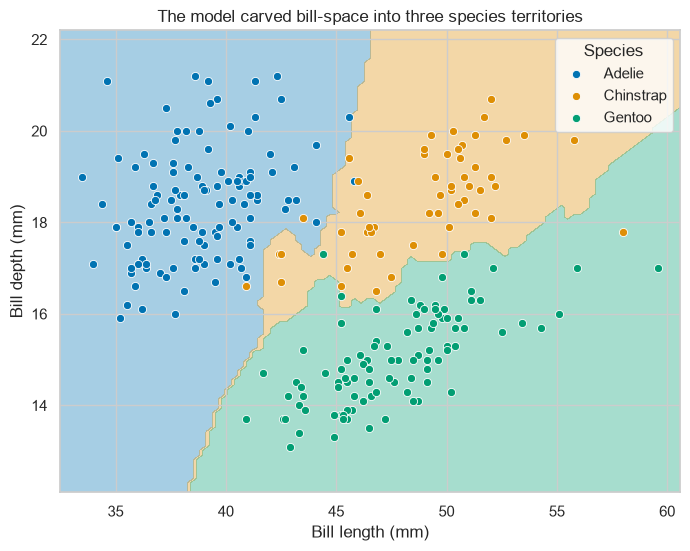

In [8]:
from sklearn.inspection import DecisionBoundaryDisplay

# One color per species, listed in ALPHABETICAL order (Adelie, Chinstrap,
# Gentoo) because that is the order the model stores its classes in --
# this makes the painted territories match our scatter-dot colors.
region_colors = [SPECIES_COLORS["Adelie"],
                 SPECIES_COLORS["Chinstrap"],
                 SPECIES_COLORS["Gentoo"]]

fig, ax = plt.subplots(figsize=(8, 6))

# from_estimator builds the grid of imaginary penguins, asks knn to predict
# every one, and paints the plot with the answers.
DecisionBoundaryDisplay.from_estimator(
    knn, X_train,
    response_method="predict",          # color by the predicted class
    multiclass_colors=region_colors,    # our species colors for the regions
    alpha=0.35,                         # translucent, so dots stay visible
    ax=ax,
    xlabel="Bill length (mm)",
    ylabel="Bill depth (mm)")

# Overlay the actual training penguins, one species at a time.
for species_name in ["Adelie", "Chinstrap", "Gentoo"]:
    is_this_species = (y_train == species_name)   # True/False mask (Module 02)
    ax.scatter(X_train[is_this_species]["bill_length_mm"],
               X_train[is_this_species]["bill_depth_mm"],
               color=SPECIES_COLORS[species_name],
               s=35, edgecolor="white", linewidth=0.6,
               label=species_name)

ax.set_title("The model carved bill-space into three species territories")
ax.legend(title="Species")
plt.show()

Read it like a range map: any future penguin landing in the blue region will be called Adélie, orange Chinstrap, green Gentoo. The borders run right through the gaps between the clouds — and the few dots sitting in the "wrong" territory are exactly the borderline penguins the model gets wrong.

## 7. Varying k — from memorizing to over-averaging

`k` is our first **hyperparameter**: a setting *we* choose rather than something the model learns. How much does it matter? Let's fit three models — k = 1, 5, 51 — and draw all three maps with their scores.

Predict before you run: with `k=1` (a single neighbor decides everything), what will the *training* accuracy be?

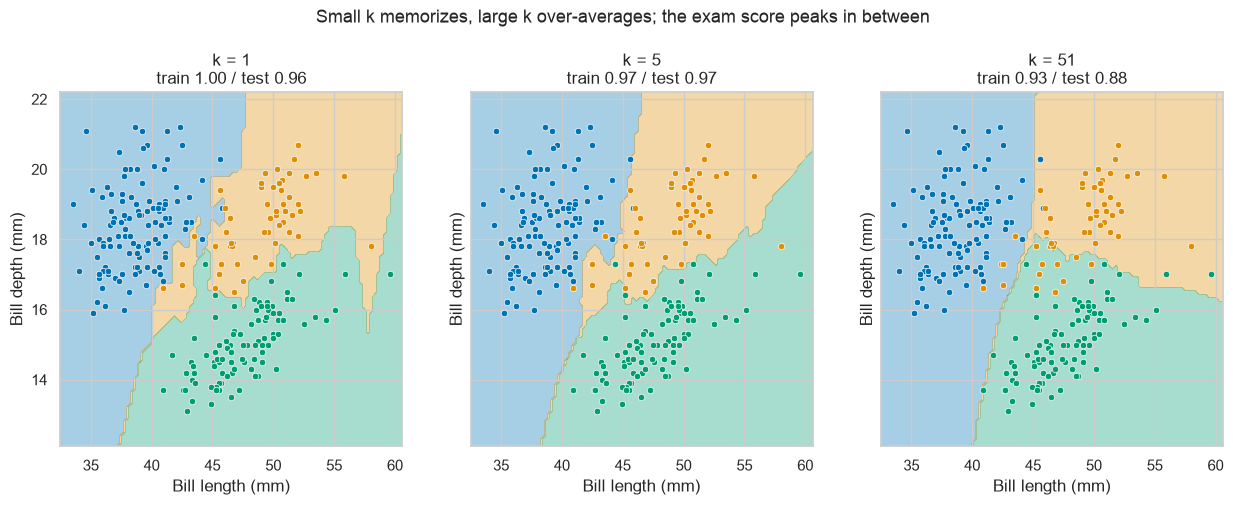

In [9]:
k_values = [1, 5, 51]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)

# One panel per k value. (plain indexed loop; axes[i] is the i-th panel)
for i in range(3):
    k = k_values[i]
    ax = axes[i]

    # Fit a fresh model with this k on the SAME training data as before.
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    # Both scores, so we can watch the memorization gap open and close.
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    # Paint this model's decision map.
    DecisionBoundaryDisplay.from_estimator(
        model, X_train, response_method="predict",
        multiclass_colors=region_colors, alpha=0.35, ax=ax,
        xlabel="Bill length (mm)",
        ylabel="Bill depth (mm)")

    # Overlay the training penguins.
    for species_name in ["Adelie", "Chinstrap", "Gentoo"]:
        is_this_species = (y_train == species_name)
        ax.scatter(X_train[is_this_species]["bill_length_mm"],
                   X_train[is_this_species]["bill_depth_mm"],
                   color=SPECIES_COLORS[species_name],
                   s=22, edgecolor="white", linewidth=0.5)

    # ':.2f' = show 2 decimal places.
    ax.set_title(f"k = {k}\ntrain {train_acc:.2f} / test {test_acc:.2f}")

fig.suptitle("Small k memorizes, large k over-averages; the exam score peaks in between",
             y=1.06, fontsize=13)
plt.show()

Three maps, one story:

- **k = 1** — training accuracy is a *perfect* 1.00: every penguin's nearest neighbor is itself, so the model "predicts" the training set by pure recall. The map is jagged, with tiny gerrymandered islands drawn around individual odd penguins. But the exam score is only 0.96 — memorizing the noise didn't transfer. This is **overfitting**: the memorizing student, caught by the held-out exam.
- **k = 51** — 51 voters smooth the borders so aggressively that real local detail is steamrolled, and *both* scores sag (train 0.93, test 0.88). This is **underfitting** — a field guide reduced to one crude question.
- **k = 5** — the sweet spot here: enough voters to ignore oddballs, few enough to respect real structure, and the best exam score of the three (0.97).

This train-flatters / test-tells pattern is the single most important habit of mind in this course.

## 8. Why feature scale matters to a distance-based model

Everything so far used two features that happen to share units (both in mm) and similar ranges. We got lucky. Now try a pair with *wildly* different scales: flipper length (millimeters) and body mass (**grams**).

k-NN judges similarity by distance. Between two penguins that differ by 20 mm of flipper and 300 g of mass, the distance is utterly dominated by the 300 — the model is effectively comparing penguins **by mass alone**, and the flipper column might as well not exist. Like comparing expression profiles without normalizing: the highest-expressed gene drowns out the rest.

In [10]:
# A new feature table: flipper (mm) and body mass (g).
X_fm = df[["flipper_length_mm", "body_mass_g"]]

# Look at the ranges: .agg(["min", "max"]) computes both summaries per column.
print(X_fm.agg(["min", "max"]))
print()

# Same split recipe as before (same random_state -> same rows in each piece).
X_fm_train, X_fm_test, y_fm_train, y_fm_test = train_test_split(
    X_fm, y, test_size=0.2, random_state=42, stratify=y)

# Fit k-NN exactly as before, k=5, no scaling.
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_fm_train, y_fm_train)

print(f"UNSCALED flipper+mass test accuracy: {knn_raw.score(X_fm_test, y_fm_test):.3f}")

     flipper_length_mm  body_mass_g
min              172.0       2700.0
max              231.0       6300.0

UNSCALED flipper+mass test accuracy: 0.716


Only ~72% — far worse than the bills gave us, even though flipper length and body mass separate the species quite well (remember the clean clusters in Module 02's scatter plot). The information is there; the ruler is broken. The flipper axis spans ~59 units while the mass axis spans ~3600, so "nearest" means "nearest in grams."

The repair is **standardization**: re-express every feature as *how many standard deviations above or below its own average* — a **z-score**, the same idea behind clinical reference ranges. After that, both features span comparable ranges and each gets a fair say in the distance. scikit-learn's `StandardScaler` learns each column's mean and standard deviation with `.fit`, then converts values with `.transform`.

One subtlety (Module 07 makes a big deal of this): the scaler learns its averages **from the training set only**. The test set must stay completely unseen — even its column averages are information.

In [11]:
from sklearn.preprocessing import StandardScaler

# Learn each column's mean and standard deviation -- from the TRAINING set only.
scaler = StandardScaler()
scaler.fit(X_fm_train)

# Convert both pieces to z-scores using those training-set statistics.
X_fm_train_scaled = scaler.transform(X_fm_train)
X_fm_test_scaled = scaler.transform(X_fm_test)

# Peek at 3 penguins before and after: big raw numbers become small z-scores.
print("before scaling (mm, g):")
print(X_fm_train.head(3))
print()
print("after scaling (z-scores, unitless):")
print(X_fm_train_scaled[:3].round(2))
print()

# Same model, same k -- only the ruler changed.
knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_fm_train_scaled, y_fm_train)

print(f"SCALED flipper+mass test accuracy: {knn_scaled.score(X_fm_test_scaled, y_fm_test):.3f}")

before scaling (mm, g):
     flipper_length_mm  body_mass_g
200              213.0       5100.0
329              203.0       4050.0
269              222.0       6000.0

after scaling (z-scores, unitless):
[[ 0.83  1.08]
 [ 0.12 -0.22]
 [ 1.48  2.19]]

SCALED flipper+mass test accuracy: 0.806


From 72% to 81% by changing *nothing about the model* — only the units. The rule to keep: **any model that computes distances gets scaled features.** (Our bills-only model survived unscaled because both bill measurements are in millimeters with similar spreads — luck, not virtue.)

## 9. The full model — four features and a brand-new penguin

No more training wheels: all four measurements, scaled, k = 5. We lose the ability to draw the map (four features = four dimensions), but the model doesn't care — distance and voting work identically in 4-D.

In [12]:
# All four numeric measurements.
X_all = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]

# Split -> scale (training statistics only) -> fit. Same recipe, four features.
X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y)

scaler_all = StandardScaler()
scaler_all.fit(X_all_train)
X_all_train_scaled = scaler_all.transform(X_all_train)
X_all_test_scaled = scaler_all.transform(X_all_test)

knn_all = KNeighborsClassifier(n_neighbors=5)
knn_all.fit(X_all_train_scaled, y_all_train)

accuracy_all = knn_all.score(X_all_test_scaled, y_all_test)
print(f"4-feature scaled test accuracy: {accuracy_all:.3f}")
print(f"that's {(knn_all.predict(X_all_test_scaled) == y_all_test.values).sum()}"
      f" of {len(y_all_test)} exam penguins correct")

4-feature scaled test accuracy: 1.000
that's 67 of 67 exam penguins correct


A perfect exam: all 67 held-out penguins identified correctly. Enjoy it — but note *why* it was possible: three well-separated species and four informative measurements. Real problems (like the heart-disease diagnosis in Module 06) rarely hand out perfect scores, and a perfect score on a hard problem should make you suspicious, not proud.

**The payoff.** A colleague radios in measurements of a penguin the dataset has never contained — we invent one: bill 45 mm long and 17 mm deep, flippers 200 mm, mass 4200 g. The model identifies it, and `predict_proba` shows the actual **vote**: what fraction of the 5 nearest neighbors belongs to each species. With k=5 the fractions come in fifths — they are literally ballots.

In [13]:
# A brand-new, made-up penguin. Same column names as X_all, in the same order.
new_penguin = pd.DataFrame({
    "bill_length_mm": [45.0],
    "bill_depth_mm": [17.0],
    "flipper_length_mm": [200.0],
    "body_mass_g": [4200.0],
})

# The new penguin must go through the SAME scaler as the training data --
# z-scores only mean something relative to the reference population.
new_penguin_scaled = scaler_all.transform(new_penguin)

# The verdict... ([0] takes the first answer -- we only asked about one penguin)
verdict = knn_all.predict(new_penguin_scaled)[0]

# ...and the vote breakdown: one fraction per species, in class order.
vote_fractions = knn_all.predict_proba(new_penguin_scaled)[0]

print("the 5 nearest neighbors voted:")
for i in range(3):
    species_name = knn_all.classes_[i]        # class names, alphabetical order
    n_votes = vote_fractions[i] * 5           # fraction of 5 voters -> ballots
    # ':.0f' = show 0 decimal places (whole ballots).
    print(f"  {species_name}: {n_votes:.0f} of 5")

print()
print(f"verdict: {verdict}")

the 5 nearest neighbors voted:
  Adelie: 1 of 5
  Chinstrap: 4 of 5
  Gentoo: 0 of 5

verdict: Chinstrap


Four of its five most similar penguins are Chinstraps, so the verdict is **Chinstrap** — with one dissenting Adélie vote, a useful reminder that this bird sits near a species border and the ID comes with real uncertainty. A 5–0 vote would mean the penguin landed deep inside one species' territory.

## Recap

| Idea | Code |
|---|---|
| Features and label | `X = df[[...]]`, `y = df["species"]` |
| Honest exam | `train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)` |
| Create + train k-NN | `KNeighborsClassifier(n_neighbors=5)`, `.fit(X_train, y_train)` |
| Predict | `.predict(X_new)`, vote breakdown with `.predict_proba(X_new)` |
| Accuracy | `.score(X_test, y_test)` — trust only the test-set number |
| The model's map | `DecisionBoundaryDisplay.from_estimator(model, X, ...)` |
| Fair ruler | `StandardScaler()`: `.fit(X_train)`, then `.transform(...)` both pieces |

Next: [exercises.md](exercises.md). Then Module 05, where the question changes from *"which species?"* to *"how many grams?"* — same workflow, numeric answers.